In [3]:
import fastf1
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

fastf1.Cache.enable_cache("../cache/")
plt.style.use("seaborn-v0_8-darkgrid")
pd.set_option("display.max_columns", 20)

In [5]:
laps = pd.read_parquet("../data/raw/laps_2023_r01.parquet")
print(laps.shape)
laps.head()

(1055, 18)


,Driver,DriverNumber,Team,LapNumber,LapTime,Compound,TyreLife,FreshTyre,Stint,IsPersonalBest,PitOutTime,PitInTime,TrackStatus,LapTimeSeconds,Year,Round,Circuit,IsPitLap
0,VER,1,Red Bull Racing,1.0,0 days 00:01:39.019000,SOFT,4.0,False,1.0,False,NaT,NaT,12,99.019,2023,1,Bahrain Grand Prix,False
1,VER,1,Red Bull Racing,2.0,0 days 00:01:37.974000,SOFT,5.0,False,1.0,True,NaT,NaT,12,97.974,2023,1,Bahrain Grand Prix,False
2,VER,1,Red Bull Racing,3.0,0 days 00:01:38.006000,SOFT,6.0,False,1.0,False,NaT,NaT,1,98.006,2023,1,Bahrain Grand Prix,False
3,VER,1,Red Bull Racing,4.0,0 days 00:01:37.976000,SOFT,7.0,False,1.0,False,NaT,NaT,1,97.976,2023,1,Bahrain Grand Prix,False
4,VER,1,Red Bull Racing,5.0,0 days 00:01:38.035000,SOFT,8.0,False,1.0,False,NaT,NaT,1,98.035,2023,1,Bahrain Grand Prix,False


In [6]:
print("Missing values:")
print(laps.isnull().sum())
print(f"\nCompounds present: {laps['Compound'].unique()}")
print(f"\nLaps per compound:")
print(laps['Compound'].value_counts())

Missing values:
Driver               0
DriverNumber         0
Team                 0
LapNumber            0
LapTime              0
Compound             0
TyreLife             0
FreshTyre            0
Stint                0
IsPersonalBest       0
PitOutTime        1005
PitInTime         1003
TrackStatus          0
LapTimeSeconds       0
Year                 0
Round                0
Circuit              0
IsPitLap             0
dtype: int64

Compounds present: ['SOFT' 'HARD' 'MEDIUM']

Laps per compound:
Compound
HARD      588
SOFT      457
MEDIUM     10
Name: count, dtype: int64


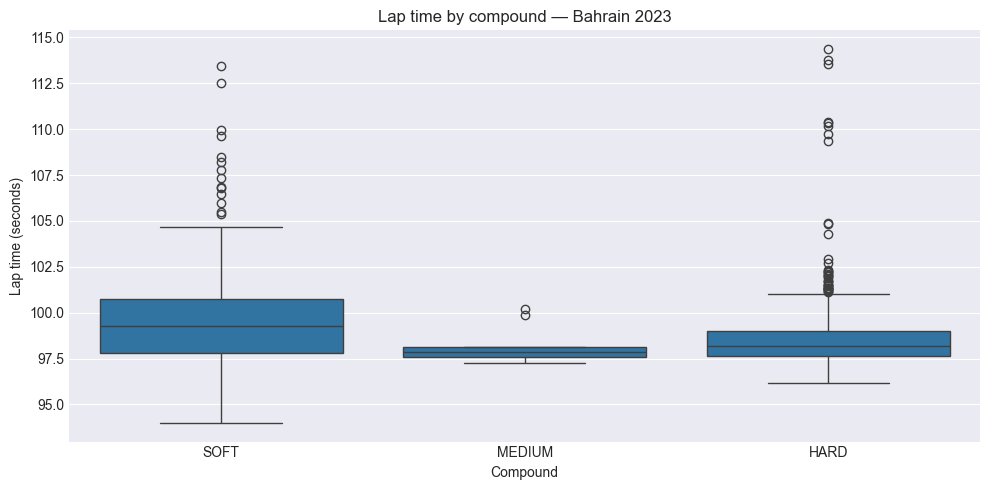

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))
compounds = laps[laps['Compound'].isin(['SOFT','MEDIUM','HARD'])]
compounds = compounds[compounds['LapTimeSeconds'].between(90, 115)]  # remove outliers

sns.boxplot(data=compounds, x='Compound', y='LapTimeSeconds', 
            order=['SOFT','MEDIUM','HARD'], ax=ax)
ax.set_title('Lap time by compound — Bahrain 2023')
ax.set_ylabel('Lap time (seconds)')
plt.tight_layout()
plt.show()

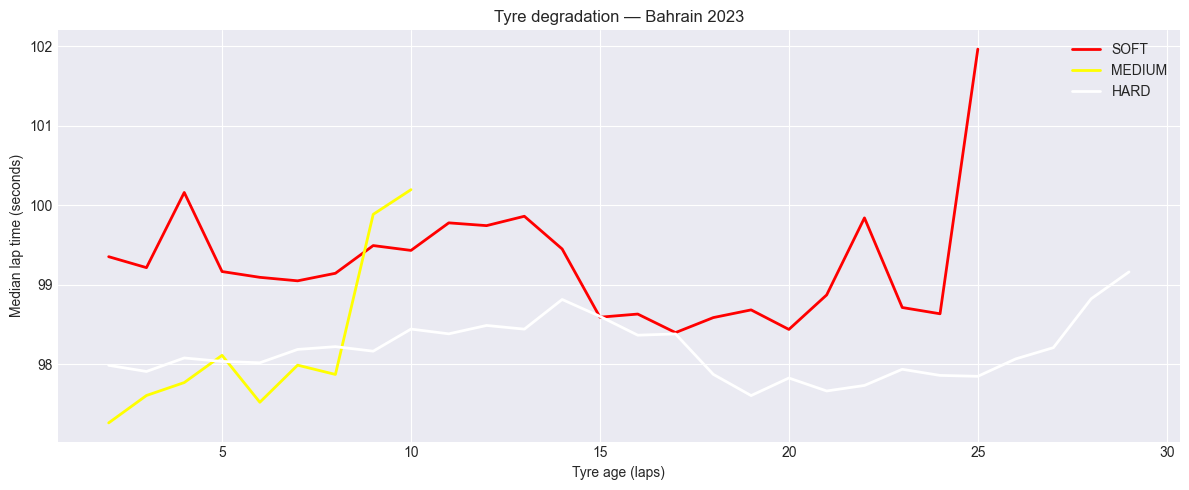

In [12]:
fig, ax = plt.subplots(figsize=(12, 5))

for compound, color in [('SOFT','red'), ('MEDIUM','yellow'), ('HARD','white')]:
    subset = laps[
        (laps['Compound'] == compound) & 
        (laps['LapTimeSeconds'].between(90, 115)) &
        (laps['TyreLife'] <= 40) &
        (laps['TyreLife'] > 1)  # remove out lap
    ]
    if len(subset) == 0:
        continue
    # Average lap time per tyre age
    avg = subset.groupby('TyreLife')['LapTimeSeconds'].median()
    ax.plot(avg.index, avg.values, label=compound, color=color, linewidth=2)

ax.set_title('Tyre degradation — Bahrain 2023')
ax.set_xlabel('Tyre age (laps)')
ax.set_ylabel('Median lap time (seconds)')
ax.legend()
plt.tight_layout()
plt.show()
fig.savefig("../notebooks/tyre_degradation_bahrain2023.png", dpi=150, bbox_inches='tight')

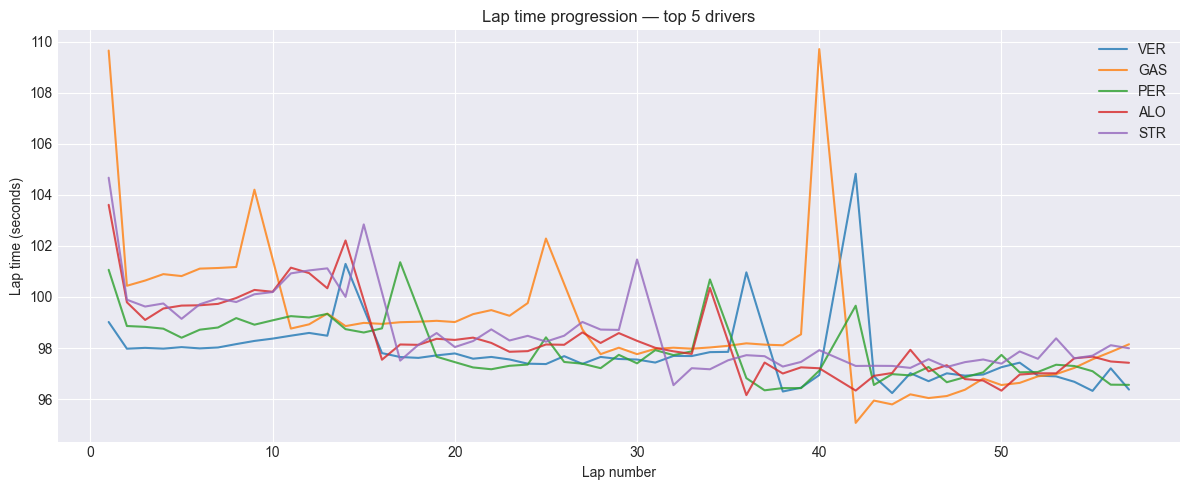

In [9]:
top_drivers = laps['Driver'].value_counts().head(5).index

fig, ax = plt.subplots(figsize=(12, 5))
for driver in top_drivers:
    d = laps[
        (laps['Driver'] == driver) & 
        (laps['LapTimeSeconds'].between(90, 115))
    ]
    ax.plot(d['LapNumber'], d['LapTimeSeconds'], label=driver, alpha=0.8)

ax.set_title('Lap time progression — top 5 drivers')
ax.set_xlabel('Lap number')
ax.set_ylabel('Lap time (seconds)')
ax.legend()
plt.tight_layout()
plt.show()

In [13]:
findings = """
Key findings — Bahrain 2023
===========================
1. Soft tyres degrade ~1s over 15 laps vs hard tyres which are almost flat
2. Pit out-laps are clear outliers (105-110s) — must filter TyreLife > 1 before training
3. Fuel load effect visible — all drivers ~1-2s faster by lap 50 vs lap 5
4. Medium tyre data sparse (<10 laps) — expect wide confidence intervals at this circuit
5. Lap time range 96-110s — filter to 90-115s removes outliers cleanly
"""
print(findings)


Key findings — Bahrain 2023
1. Soft tyres degrade ~1s over 15 laps vs hard tyres which are almost flat
2. Pit out-laps are clear outliers (105-110s) — must filter TyreLife > 1 before training
3. Fuel load effect visible — all drivers ~1-2s faster by lap 50 vs lap 5
4. Medium tyre data sparse (<10 laps) — expect wide confidence intervals at this circuit
5. Lap time range 96-110s — filter to 90-115s removes outliers cleanly

